<a href="https://colab.research.google.com/github/riyamehta12/speech_impairement_recognition/blob/main/aiml.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install librosa
!pip install openai-whisper

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 800.5/800.5 kB 8.0 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 24.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 57.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 57.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 29.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 12.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 6.2 MB/s e

Enter paths to audio files (comma-separated): /content/New Recording 3.wav


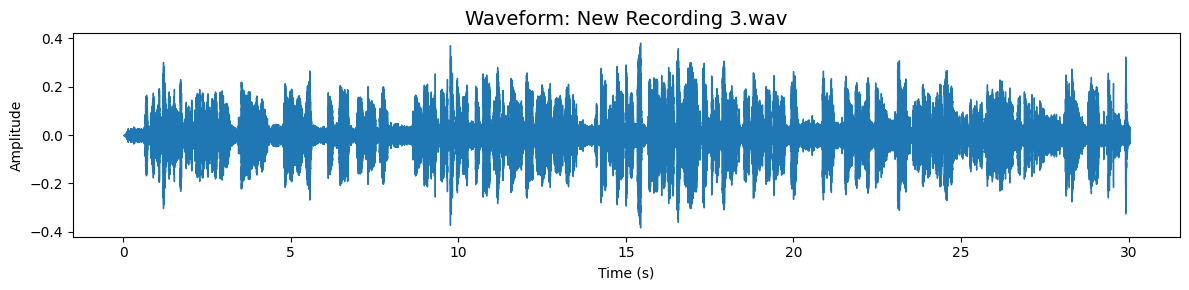

/usr/local/lib/python3.11/dist-packages/whisper/transcribe.py:126: UserWarning: FP16 is not supported on CPU; using FP32 instead
  warnings.warn("FP16 is not supported on CPU; using FP32 instead")



📝 Transcript for New Recording 3.wav:
 [okay], [so] this is the second recording in which i'm training my m&m model. and here i'm trying to convey a speech that is not impaired, [so] affluent or normal or a healthy speech. [so] i hope in my model this shows that the impairment is minus one or not there. [so] i'm very happy that i'm done with the model. i guess when i have a lot of time on it and i'm hoping the task is done. [well], thank you.

📊 Features:
- Pitch Variability: 781.030029296875 Hz
- Avg Pitch: 970.4299926757812 Hz
- Repetitions: 1
- Fillers: 6
- Pauses: 1
- Speech Rate: 163.8 WPM

✅ FINAL RISK SUMMARY:
                     anomaly_score  anomalies_per_minute  svm_anomaly  iso_forest_anomaly  tree_anomaly  final_score_avg  final_verdict
New Recording 3.wav              2              3.995028           -1                   1         False             0.25          False


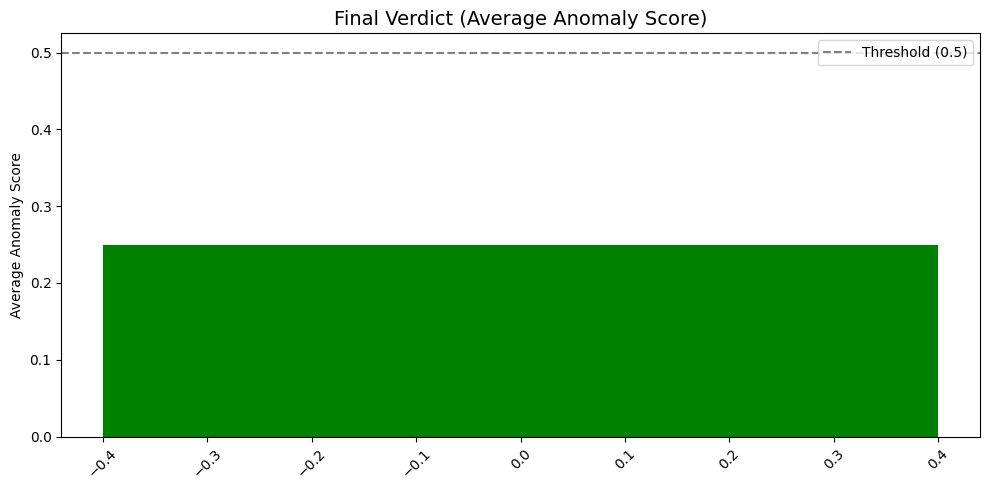

In [21]:
import os
import librosa
import librosa.display
import numpy as np
import matplotlib.pyplot as plt
import whisper
import re
from collections import Counter
import pandas as pd

from sklearn.preprocessing import StandardScaler
from sklearn.svm import OneClassSVM
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import IsolationForest

# ======================== INPUT ========================
audio_paths = input("Enter paths to audio files (comma-separated): ").split(',')

# ======================== AUDIO LOADING & VISUALIZATION ========================
def load_audio(file_path):
    y, sr = librosa.load(file_path.strip(), sr=None)
    duration = librosa.get_duration(y=y, sr=sr)
    return y, sr, duration

def plot_waveform(y, sr, title):
    plt.figure(figsize=(12, 3))
    librosa.display.waveshow(y, sr=sr)
    plt.title(title, fontsize=14)
    plt.xlabel("Time (s)")
    plt.ylabel("Amplitude")
    plt.tight_layout()
    plt.show()

# ======================== AUDIO FEATURE EXTRACTION ========================
def extract_audio_features(y, sr):
    pitches, magnitudes = librosa.piptrack(y=y, sr=sr)
    voiced = pitches[magnitudes > 0]

    return {
        "rms": np.mean(librosa.feature.rms(y=y)),
        "zcr": np.mean(librosa.feature.zero_crossing_rate(y)),
        "spectral_centroid": np.mean(librosa.feature.spectral_centroid(y=y, sr=sr)),
        "spectral_bandwidth": np.mean(librosa.feature.spectral_bandwidth(y=y, sr=sr)),
        "spectral_rolloff": np.mean(librosa.feature.spectral_rolloff(y=y, sr=sr)),
        "spectral_contrast": np.mean(librosa.feature.spectral_contrast(y=y, sr=sr)),
        "mfcc": np.mean(librosa.feature.mfcc(y=y, sr=sr)),
        "average_pitch": np.mean(voiced),
        "pitch_variability": np.std(voiced)
    }

# ======================== NLP FEATURE EXTRACTION ========================
model = whisper.load_model("base")
filler_words = [
    "um", "uh", "ah", "hmm", "like", "you know", "so", "well", "actually",
    "basically", "right", "okay", "i mean", "sort of", "kind of", "what do you call"
]

def highlight_filler_words(text, fillers):
    for filler in fillers:
        text = re.sub(rf"\b{filler}\b", f"[{filler}]", text)
    return text

def detect_repetitions(transcript, window_size=3):
    words = transcript.split()
    repetitions = Counter()
    for i in range(len(words) - window_size + 1):
        for j in range(i + 1, i + window_size):
            if words[i] == words[j]:
                repetitions[words[i]] += 1
                break
    return repetitions

def count_fillers(transcript, fillers):
    return sum(len(re.findall(rf"\b{filler}\b", transcript)) for filler in fillers)

def detect_pauses(segments, threshold=0.5):
    return sum(1 for i in range(len(segments) - 1)
               if segments[i+1]["start"] - segments[i]["end"] > threshold)

# ======================== EXTRACT ALL FEATURES ========================
def extract_all_features(file_path):
    y, sr, duration = load_audio(file_path)
    plot_waveform(y, sr, f"Waveform: {os.path.basename(file_path)}")

    result = model.transcribe(file_path, word_timestamps=True)
    text = result['text'].lower()
    segments = result.get("segments", [])
    num_words = len(text.split())
    speech_rate = (num_words / duration) * 60

    audio_feats = extract_audio_features(y, sr)
    fillers = count_fillers(text, filler_words)
    repetitions = detect_repetitions(text)
    pauses = detect_pauses(segments)

    print(f"\n📝 Transcript for {os.path.basename(file_path)}:")
    print(highlight_filler_words(text, filler_words))
    print(f"\n📊 Features:\n- Pitch Variability: {round(audio_feats['pitch_variability'], 2)} Hz")
    print(f"- Avg Pitch: {round(audio_feats['average_pitch'], 2)} Hz")
    print(f"- Repetitions: {sum(repetitions.values())}")
    print(f"- Fillers: {fillers}")
    print(f"- Pauses: {pauses}")
    print(f"- Speech Rate: {round(speech_rate, 2)} WPM")

    return {
        **audio_feats,
        "num_filler_words": fillers,
        "num_repetitions": sum(repetitions.values()),
        "num_pauses": pauses,
        "speech_rate_wpm": speech_rate
    }, y, sr, duration

# ======================== RULE-BASED SCORING ========================
def anomaly_score(f, duration):
    score = 0
    if f['pitch_variability'] > 80: score += 1
    if f['num_filler_words'] > 3: score += 1
    if f['num_repetitions'] > 1: score += 1
    if f['num_pauses'] > 2: score += 1
    if f['speech_rate_wpm'] < 110: score += 1
    anomalies_per_minute = score / (duration / 60)
    return score, anomalies_per_minute

# ======================== MAIN LOOP ========================
feature_list = []
audio_data = []

for path in audio_paths:
    path = path.strip()
    features, y, sr, duration = extract_all_features(path)
    score, apm = anomaly_score(features, duration)

    features['anomaly_score'] = score
    features['anomalies_per_minute'] = apm
    feature_list.append(features)
    audio_data.append((y, sr, path))

df = pd.DataFrame(feature_list)

# ======================== MACHINE LEARNING DETECTION ========================
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[[
    'pitch_variability',
    'num_filler_words',
    'num_repetitions',
    'num_pauses',
    'speech_rate_wpm'
]])

svm = OneClassSVM().fit(X_scaled)
iso_forest = IsolationForest(random_state=0).fit(X_scaled)
tree = DecisionTreeClassifier(random_state=0).fit(X_scaled, df['anomaly_score'] > 2)

df['svm_anomaly'] = svm.predict(X_scaled)
df['iso_forest_anomaly'] = iso_forest.predict(X_scaled)
df['tree_anomaly'] = tree.predict(X_scaled)

# ======================== AVERAGED FINAL VERDICT ========================
df['final_score_avg'] = (
    ((df['anomaly_score'] > 2).astype(int) +
     (df['svm_anomaly'] == -1).astype(int) +
     (df['iso_forest_anomaly'] == -1).astype(int) +
     (df['tree_anomaly'] == 1).astype(int)) / 4
)

df['final_verdict'] = df['final_score_avg'] >= 0.5

# ======================== PRINT SUMMARY ========================
summary = df[[
    'anomaly_score',
    'anomalies_per_minute',
    'svm_anomaly',
    'iso_forest_anomaly',
    'tree_anomaly',
    'final_score_avg',
    'final_verdict'
]]
summary.index = [os.path.basename(p.strip()) for p in audio_paths]

print("\n✅ FINAL RISK SUMMARY:")
print(summary.to_string())

# ======================== PLOT FINAL VERDICT ========================
def plot_final_verdict(df):
    plt.figure(figsize=(10, 5))
    labels = df.index
    colors = ['green' if not verdict else 'red' for verdict in df['final_verdict']]
    values = df['final_score_avg']

    plt.bar(labels, values, color=colors)
    plt.axhline(y=0.5, color='gray', linestyle='--', label="Threshold (0.5)")
    plt.title("Final Verdict (Average Anomaly Score)", fontsize=14)
    plt.ylabel("Average Anomaly Score")
    plt.xticks(rotation=45)
    plt.legend()
    plt.tight_layout()
    plt.show()

plot_final_verdict(df)


